Number of trades: 131
Win rate (net) %: 49.6
Avg trade net %: -0.083
Total return gross %: -11.9
Total return net %: -22.7
Max drawdown (net, trade-level) %: -52.7
Buy & hold total return %: 336.8 | max drawdown %: -59.9
Time in market %: 14.0


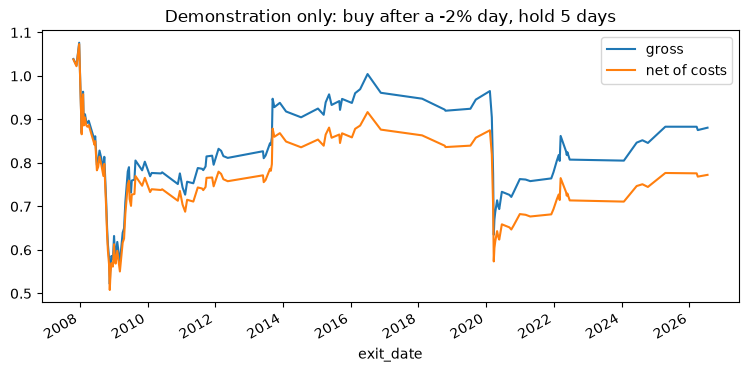

In [1]:
import sys; sys.path.append("../src")
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from engine import *

df = load_clean()
cfg = Config(threshold=-0.02, hold=5)
cost = 2 * cfg.cost_per_side          # 0.10% round trip (brokerage + slippage)

trades = get_events(df, cfg)[["ret", "entry_price", "exit_date", "exit_price", "fwd_ret"]].copy()
trades["net_ret"] = trades["fwd_ret"] - cost
trades = trades.set_index("exit_date")

gross_eq = (1 + trades["fwd_ret"]).cumprod()
net_eq   = (1 + trades["net_ret"]).cumprod()
max_dd   = (net_eq / net_eq.cummax() - 1).min()

first_entry = df.loc[df.index > get_events(df, cfg).index[0], "Open"].iloc[0]
bh = df.loc[get_events(df, cfg).index[0]:, "Close"]
bh_ret = bh.iloc[-1] / first_entry - 1
bh_dd = (bh / bh.cummax() - 1).min()

print("Number of trades:", len(trades))
print("Win rate (net) %:", round((trades["net_ret"] > 0).mean() * 100, 1))
print("Avg trade net %:", round(trades["net_ret"].mean() * 100, 3))
print("Total return gross %:", round((gross_eq.iloc[-1] - 1) * 100, 1))
print("Total return net %:", round((net_eq.iloc[-1] - 1) * 100, 1))
print("Max drawdown (net, trade-level) %:", round(max_dd * 100, 1))
print("Buy & hold total return %:", round(bh_ret * 100, 1), "| max drawdown %:", round(bh_dd * 100, 1))
print("Time in market %:", round(len(trades) * cfg.hold / len(df) * 100, 1))

plt.figure(figsize=(9, 4))
gross_eq.plot(label="gross"); net_eq.plot(label="net of costs")
plt.title("Demonstration only: buy after a -2% day, hold 5 days"); plt.legend(); plt.show()

Demonstration only. The research found no evidence of an edge, so this is not a proposed strategy.
Rules: signal = close-to-close return <= -2%; buy at next open; sell at close of day 5;
one position at a time; 0.05% cost per side; 100% of capital per trade.
Limitation: drawdown is measured on trade-level equity, so it understates intra-trade drawdown.
It also covers the full sample, including the OOS period, so it is not an out-of-sample test.